import 

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
DATA_FILE = Path(
    r"C:\Users\tawac\Documents\SEM UT at Dallas Program"
    r"\SEM_JD_Market_Research_2026-06-17"
    r"\portfolio\permian_type_curve"
    r"\data\processed\martin_selected_30_monthly_production_normalized.csv"
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)    

In [25]:
df = pd.read_csv(DATA_FILE, dtype={"api8": str, "lease_no": str, "district": str})
df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202201,1,27270.0,26374.0,31665.666667,10036.0,202201,202201,1
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202202,2,25100.0,24522.0,29187.000000,10036.0,202201,202201,2
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202203,3,22589.0,23927.0,26576.833333,10036.0,202201,202201,3
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202204,4,18960.0,20036.0,22299.333333,10036.0,202201,202201,4
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202205,5,18050.0,17744.0,21007.333333,10036.0,202201,202201,5


In [27]:
numeric_columns = [
    "month_on_production",
    "oil_bbl",
    "casinghead_gas_mcf",
    "boe",
    "interval_length_proxy_ft",
]

In [29]:
df = df.sort_values(["api8", "month_on_production"]).reset_index(drop=True)


In [31]:
df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202201,1,27270.0,26374.0,31665.666667,10036.0,202201,202201,1
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202202,2,25100.0,24522.0,29187.000000,10036.0,202201,202201,2
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202203,3,22589.0,23927.0,26576.833333,10036.0,202201,202201,3
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202204,4,18960.0,20036.0,22299.333333,10036.0,202201,202201,4
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202205,5,18050.0,17744.0,21007.333333,10036.0,202201,202201,5


In [33]:
train = df[df["month_on_production"].between(1, 24)].copy()
test = df[df["month_on_production"].between(25, 33)].copy()

In [35]:
print(f"Training rows: {len(train):,}")
print(f"Testing rows: {len(test):,}")
print(f"Training wells: {train['api8'].nunique():,}")
print(f"Testing wells: {test['api8'].nunique():,}")

Training rows: 720
Testing rows: 270
Training wells: 30
Testing wells: 30


In [37]:
median_curve = (
    df[df["month_on_production"].between(1, 33)]
    .groupby("month_on_production", as_index=False)
    .agg(median_oil_bbl=("oil_bbl", "median"))
)

median_curve.head()

,month_on_production,median_oil_bbl
0,1,12627.5
1,2,29502.5
2,3,22872.5
3,4,18845.5
4,5,17784.5


In [39]:
def fit_exponential_decline(curve, month_column, rate_column, start_month=2, end_month=24):
    fit_data = curve[curve[month_column].between(start_month, end_month)].copy()
    fit_data = fit_data[fit_data[rate_column] > 0].copy()
    
    x = fit_data[month_column].to_numpy(dtype=float)
    y = fit_data[rate_column].to_numpy(dtype=float)

    slope, intercept = np.polyfit(x, np.log(y), 1)

    qi = float(np.exp(intercept))
    di = float(-slope)

    return qi, di, fit_data

def predict_exponential(months, qi, di):
    months = np.asarray(months, dtype=float)
    return qi * np.exp(-di * months)

median_qi, median_di, median_fit_data = fit_exponential_decline(
    median_curve,
    month_column="month_on_production",
    rate_column="median_oil_bbl",
)

print(f"Median curve fitted qi: {median_qi:,.0f} bbl/month")
print(f"Median curve fitted Di: {median_di:.4f} per month")
print(f"Median curve fitted Di: {median_di * 100:.2f}% per month")
    

Median curve fitted qi: 24,736 bbl/month
Median curve fitted Di: 0.0836 per month
Median curve fitted Di: 8.36% per month


In [41]:
plot_months = np.arange(1, 34)
median_curve["exp_fit_oil_bbl"] = predict_exponential(plot_months, median_qi, median_di)


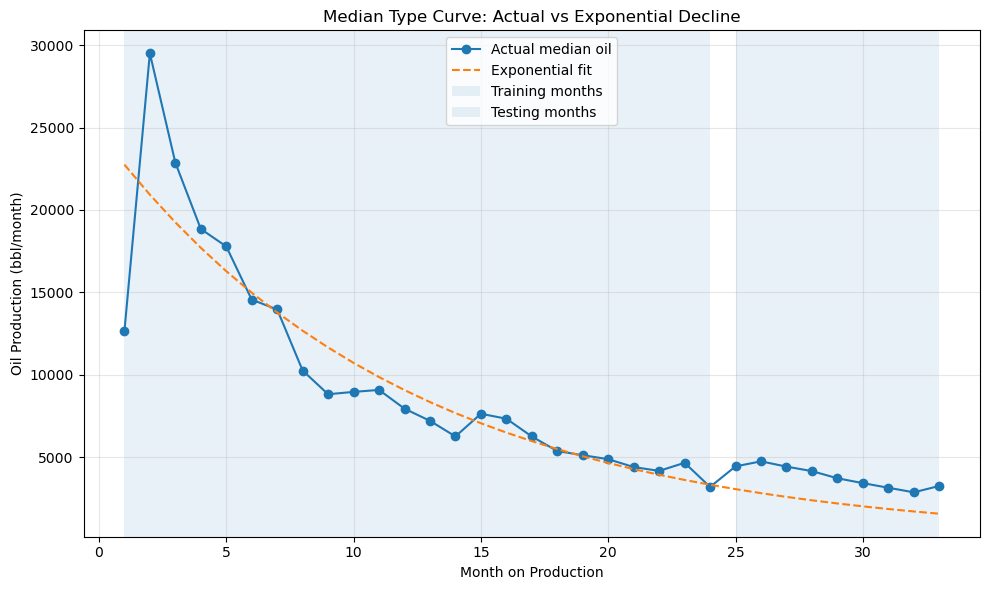

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(median_curve["month_on_production"], median_curve["median_oil_bbl"], marker="o", label="Actual median oil")
plt.plot(median_curve["month_on_production"], median_curve["exp_fit_oil_bbl"], linestyle="--", label="Exponential fit")
plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")
plt.title("Median Type Curve: Actual vs Exponential Decline")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "median_exponential_decline_fit.png", dpi=150)
plt.show()

In [59]:
late_qi, late_di, late_fit_data = fit_exponential_decline(
    median_curve,
    month_column="month_on_production",
    rate_column="median_oil_bbl",
    start_month=12,
    end_month=24,
)

print(f"Late-window fitted qi: {late_qi:,.0f} bbl/month")
print(f"Late-window fitted Di: {late_di:.4f} per month")
print(f"Late-window fitted Di: {late_di * 100:.2f}% per month")


fit_comparison = pd.DataFrame(
    [
        {
            "fit_name": "broad_fit_months_2_24",
            "fit_start_month": 2,
            "fit_end_month": 24,
            "qi_bbl_per_month": median_qi,
            "di_per_month": median_di,
            "di_percent_per_month": median_di * 100,
        },
        {
            "fit_name": "late_fit_months_12_24",
            "fit_start_month": 12,
            "fit_end_month": 24,
            "qi_bbl_per_month": late_qi,
            "di_per_month": late_di,
            "di_percent_per_month": late_di * 100,
        },
    ]
)

fit_comparison

Late-window fitted qi: 18,039 bbl/month
Late-window fitted Di: 0.0657 per month
Late-window fitted Di: 6.57% per month


,fit_name,fit_start_month,fit_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month
0,broad_fit_months_2_24,2,24,24736.171061,0.083629,8.362933
1,late_fit_months_12_24,12,24,18039.241715,0.065658,6.565810


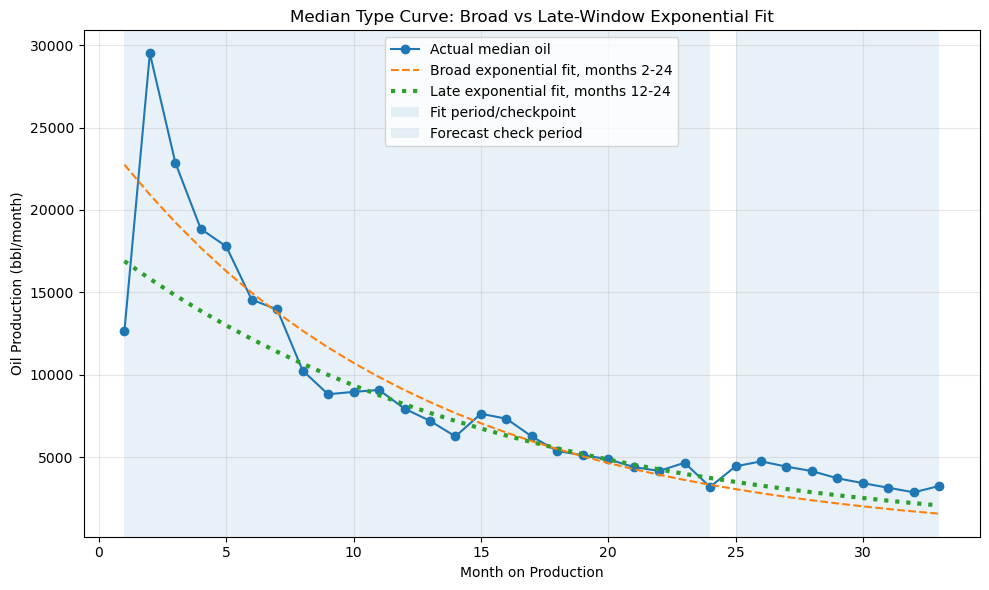

In [61]:
median_curve["broad_exp_fit_oil_bbl"] = predict_exponential(
    plot_months,
    median_qi,
    median_di,
)

median_curve["late_exp_fit_oil_bbl"] = predict_exponential(
    plot_months,
    late_qi,
    late_di,
)

plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["broad_exp_fit_oil_bbl"],
    linestyle="--",
    label="Broad exponential fit, months 2-24",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["late_exp_fit_oil_bbl"],
    linestyle=":",
    linewidth=3,
    label="Late exponential fit, months 12-24",
)

plt.axvspan(1, 24, alpha=0.10, label="Fit period/checkpoint")
plt.axvspan(25, 33, alpha=0.10, label="Forecast check period")

plt.title("Median Type Curve: Broad vs Late-Window Exponential Fit")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

## DCA Diagnostic Plots

Before selecting a final decline model, we inspect diagnostic plots. These plots help us understand whether the production behavior looks exponential, hyperbolic, boundary-dominated, transient, or affected by operating changes. The goal is not to force a model immediately, but to understand the production behavior first.

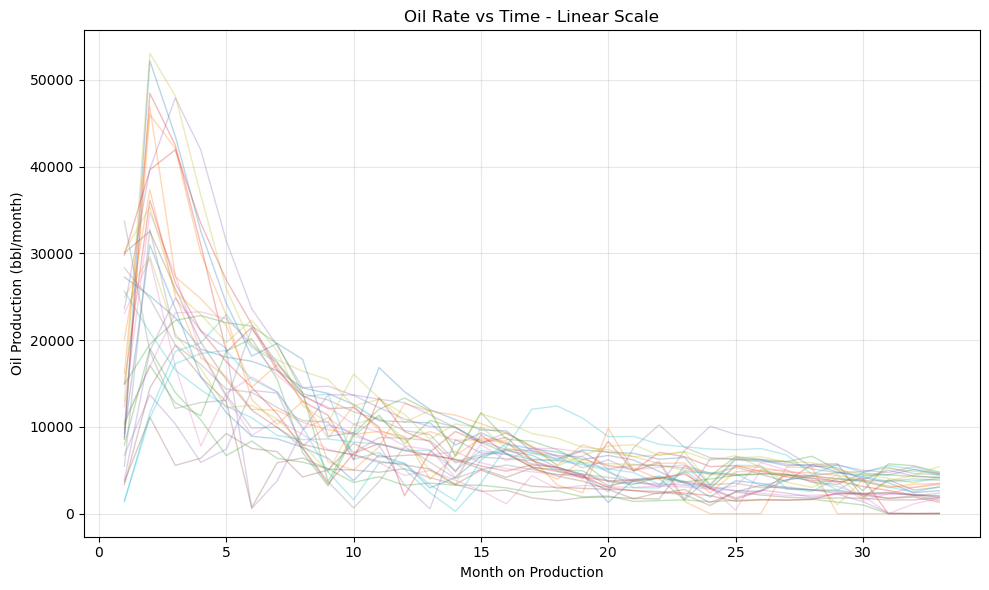

In [63]:
diagnostic_df = df[df["month_on_production"].between(1, 33)].copy()

diagnostic_df["cum_oil_bbl"] = (
    diagnostic_df
    .groupby("api8")["oil_bbl"]
    .cumsum()
)

plt.figure(figsize=(10, 6))

for api8, well_data in diagnostic_df.groupby("api8"):
    plt.plot(
        well_data["month_on_production"],
        well_data["oil_bbl"],
        alpha=0.30,
        linewidth=1,
    )

plt.title("Oil Rate vs Time - Linear Scale")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

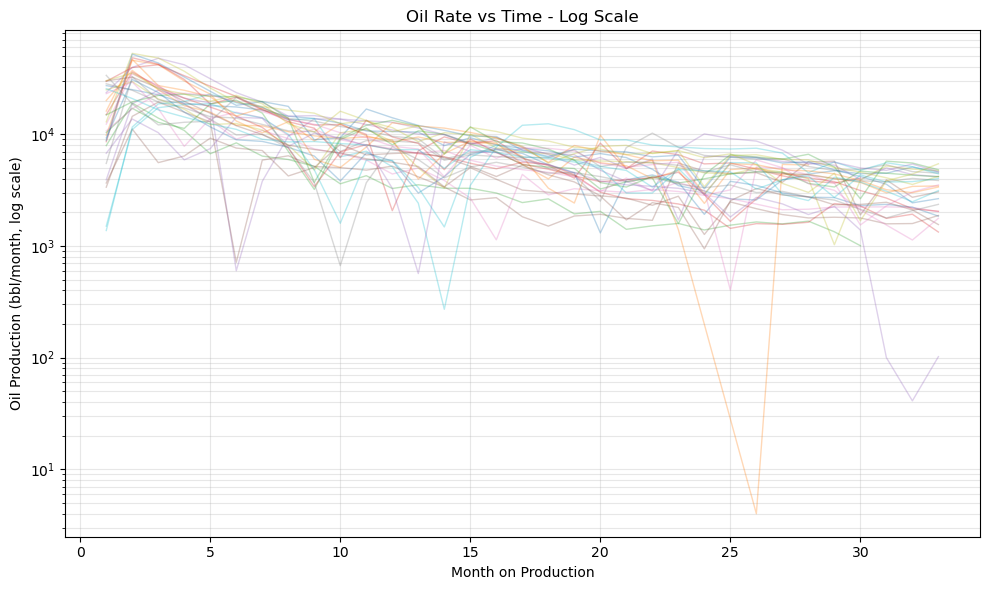

In [65]:
positive_oil_df = diagnostic_df[diagnostic_df["oil_bbl"] > 0].copy()

plt.figure(figsize=(10, 6))

for api8, well_data in positive_oil_df.groupby("api8"):
    plt.plot(
        well_data["month_on_production"],
        well_data["oil_bbl"],
        alpha=0.30,
        linewidth=1,
    )

plt.yscale("log")
plt.title("Oil Rate vs Time - Log Scale")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month, log scale)")
plt.grid(True, which="both", alpha=0.30)
plt.tight_layout()
plt.show()

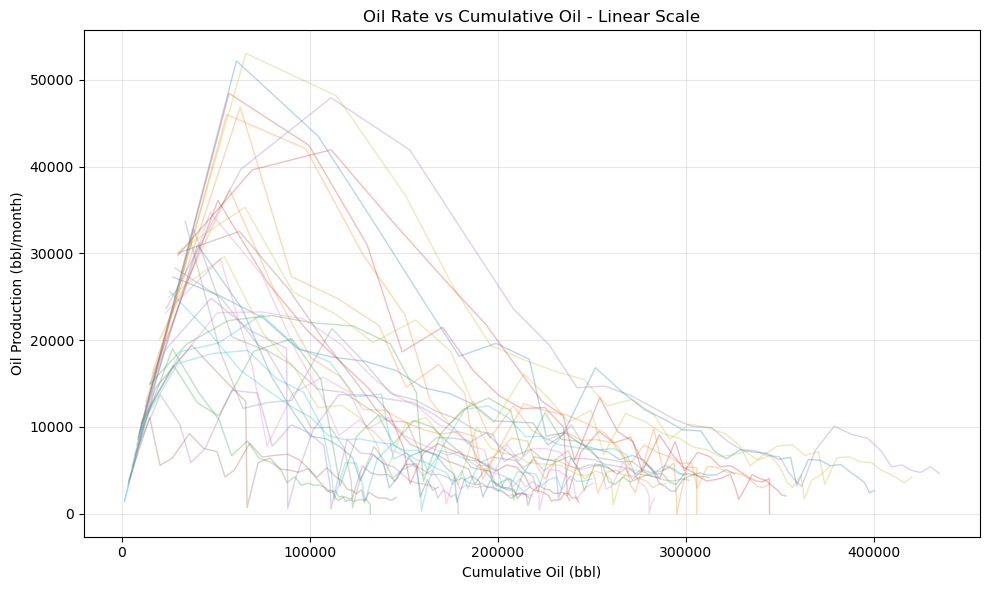

In [67]:
plt.figure(figsize=(10, 6))

for api8, well_data in diagnostic_df.groupby("api8"):
    plt.plot(
        well_data["cum_oil_bbl"],
        well_data["oil_bbl"],
        alpha=0.30,
        linewidth=1,
    )

plt.title("Oil Rate vs Cumulative Oil - Linear Scale")
plt.xlabel("Cumulative Oil (bbl)")
plt.ylabel("Oil Production (bbl/month)")
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

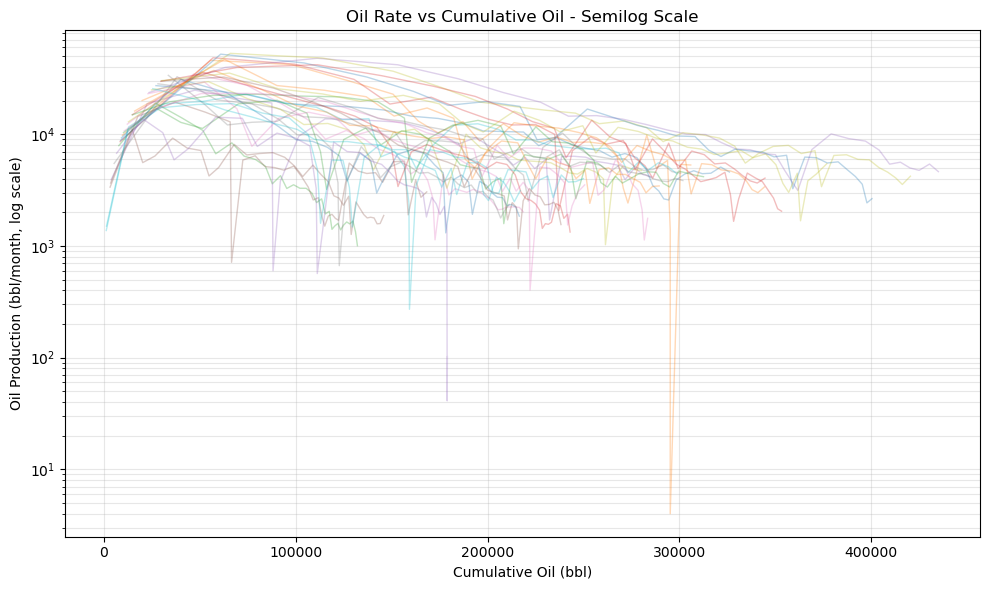

In [68]:
positive_oil_cum_df = diagnostic_df[
    (diagnostic_df["oil_bbl"] > 0)
    & (diagnostic_df["cum_oil_bbl"] > 0)
].copy()

plt.figure(figsize=(10, 6))

for api8, well_data in positive_oil_cum_df.groupby("api8"):
    plt.plot(
        well_data["cum_oil_bbl"],
        well_data["oil_bbl"],
        alpha=0.30,
        linewidth=1,
    )

plt.yscale("log")
plt.title("Oil Rate vs Cumulative Oil - Semilog Scale")
plt.xlabel("Cumulative Oil (bbl)")
plt.ylabel("Oil Production (bbl/month, log scale)")
plt.grid(True, which="both", alpha=0.30)
plt.tight_layout()
plt.show()

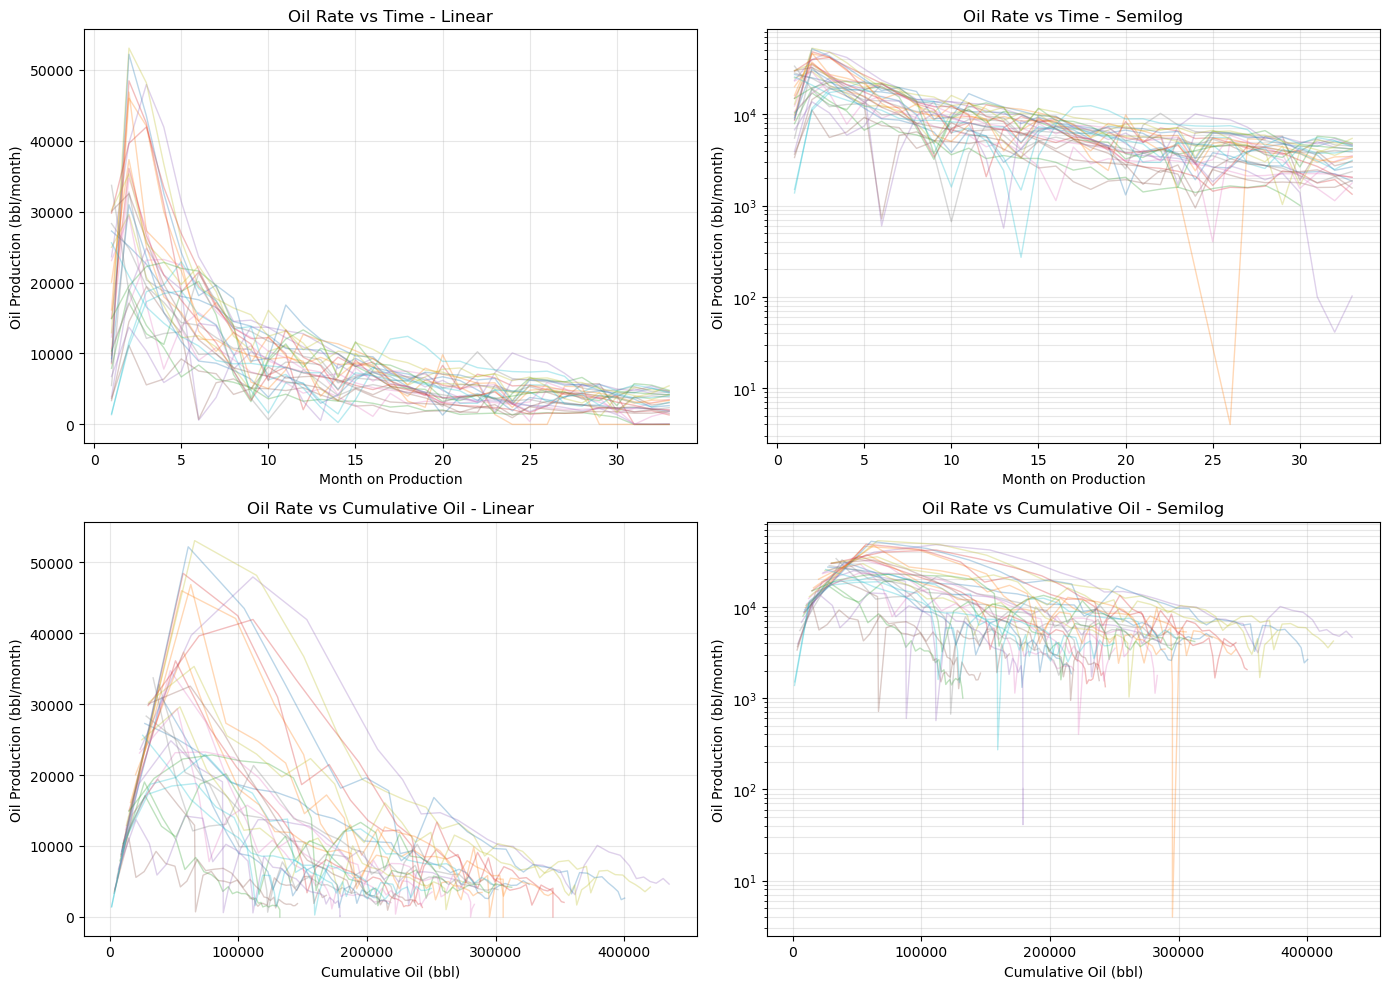

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for api8, well_data in diagnostic_df.groupby("api8"):
    axes[0, 0].plot(well_data["month_on_production"], well_data["oil_bbl"], alpha=0.30, linewidth=1)

for api8, well_data in positive_oil_df.groupby("api8"):
    axes[0, 1].plot(well_data["month_on_production"], well_data["oil_bbl"], alpha=0.30, linewidth=1)

for api8, well_data in diagnostic_df.groupby("api8"):
    axes[1, 0].plot(well_data["cum_oil_bbl"], well_data["oil_bbl"], alpha=0.30, linewidth=1)

for api8, well_data in positive_oil_cum_df.groupby("api8"):
    axes[1, 1].plot(well_data["cum_oil_bbl"], well_data["oil_bbl"], alpha=0.30, linewidth=1)

axes[0, 0].set_title("Oil Rate vs Time - Linear")
axes[0, 1].set_title("Oil Rate vs Time - Semilog")
axes[1, 0].set_title("Oil Rate vs Cumulative Oil - Linear")
axes[1, 1].set_title("Oil Rate vs Cumulative Oil - Semilog")

axes[0, 1].set_yscale("log")
axes[1, 1].set_yscale("log")

for ax in axes.flatten():
    ax.grid(True, which="both", alpha=0.30)

axes[0, 0].set_xlabel("Month on Production")
axes[0, 1].set_xlabel("Month on Production")
axes[1, 0].set_xlabel("Cumulative Oil (bbl)")
axes[1, 1].set_xlabel("Cumulative Oil (bbl)")

axes[0, 0].set_ylabel("Oil Production (bbl/month)")
axes[0, 1].set_ylabel("Oil Production (bbl/month)")
axes[1, 0].set_ylabel("Oil Production (bbl/month)")
axes[1, 1].set_ylabel("Oil Production (bbl/month)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "oil_dca_diagnostic_summary.png", dpi=150)
plt.show()

In [ ]:
diagnostic_df.to_csv(OUTPUT_DIR / "oil_dca_diagnostic_data.csv", index=False)
OUTPUT_DIR / "oil_dca_diagnostic_data.csv"

## DCA Diagnostics Checkpoint

Before selecting a final decline model, we created diagnostic plots for oil production using the full 30-well coverage window, months 1-33.

Plots created:

- Oil rate vs time on linear scale
- Oil rate vs time on semilog scale
- Oil rate vs cumulative oil on linear scale
- Oil rate vs cumulative oil on semilog scale

Why this matters:

The first exponential decline fit was useful as a baseline, but DCA should not rely only on an automatic curve fit. Diagnostic plots help show whether the data supports exponential decline, whether the later-time trend differs from early-time behavior, and whether the forecast should honor more recent production behavior.

Current interpretation:

The rate-time plot is useful as a final forecast check. The semilog rate-time plot helps assess whether exponential decline is reasonable. The rate-cumulative plots help evaluate how production rate changes as cumulative oil increases.

Water-cut diagnostics are deferred because this dataset does not currently include water production.

GOR diagnostics can be added later because the dataset includes casinghead gas.

Diagnostics suggest the production behavior may not be purely exponential. However, this notebook intentionally completes the exponential decline workflow first as a baseline. Hyperbolic and harmonic decline will be evaluated separately in a later notebook.

## Exponential DCA Scope Decision

The diagnostic plots suggest that some wells may not follow a purely exponential decline trend. Some behavior appears closer to hyperbolic or harmonic decline.

For this notebook, we will still complete the exponential decline workflow first. This gives us a clean baseline model that can later be compared against hyperbolic and harmonic decline models.

Current scope for this notebook:

- Fit exponential decline to each well individually
- Use the same fitting window for each well
- Forecast months 25-33
- Compare forecasted oil against actual oil
- Save per-well exponential DCA results

Hyperbolic and harmonic decline, including b-factor estimation, will be handled in a later notebook.

## Per-Well Exponential Decline Fits

Now we fit exponential decline separately for each well.

This is different from the median type-curve fit. The median type curve gives one representative cohort-level curve, while per-well fitting gives one decline estimate per API/well.

For each well, we will:

1. Use months 12-24 as the fitting window.
2. Estimate exponential decline parameters `qi` and `Di`.
3. Forecast months 25-33.
4. Compare forecasted oil to actual oil.

In [73]:
PER_WELL_FIT_START_MONTH = 12
PER_WELL_FIT_END_MONTH = 24
FORECAST_START_MONTH = 25
FORECAST_END_MONTH = 33

per_well_results = []

for api8, well_data in df.groupby("api8"):
    well_curve = well_data[well_data["month_on_production"].between(1, 33)].copy()

    if len(well_curve) < FORECAST_END_MONTH:
        continue

    qi, di, fit_data = fit_exponential_decline(
        well_curve,
        month_column="month_on_production",
        rate_column="oil_bbl",
        start_month=PER_WELL_FIT_START_MONTH,
        end_month=PER_WELL_FIT_END_MONTH,
    )

    forecast_data = well_curve[
        well_curve["month_on_production"].between(FORECAST_START_MONTH, FORECAST_END_MONTH)
    ].copy()

    forecast_months = forecast_data["month_on_production"].to_numpy(dtype=float)
    forecast_data["exp_forecast_oil_bbl"] = predict_exponential(forecast_months, qi, di)

    actual_test_oil_bbl = forecast_data["oil_bbl"].sum()
    forecast_test_oil_bbl = forecast_data["exp_forecast_oil_bbl"].sum()
    error_bbl = forecast_test_oil_bbl - actual_test_oil_bbl
    percent_error = error_bbl / actual_test_oil_bbl * 100

    per_well_results.append(
        {
            "api8": api8,
            "lease_name": well_curve["lease_name"].iloc[0],
            "well_no": well_curve["well_no"].iloc[0],
            "fit_start_month": PER_WELL_FIT_START_MONTH,
            "fit_end_month": PER_WELL_FIT_END_MONTH,
            "forecast_start_month": FORECAST_START_MONTH,
            "forecast_end_month": FORECAST_END_MONTH,
            "qi_bbl_per_month": qi,
            "di_per_month": di,
            "di_percent_per_month": di * 100,
            "actual_test_oil_bbl": actual_test_oil_bbl,
            "forecast_test_oil_bbl": forecast_test_oil_bbl,
            "error_bbl": error_bbl,
            "percent_error": percent_error,
        }
    )

In [75]:
per_well_results_df = pd.DataFrame(per_well_results)

per_well_results_df = per_well_results_df.sort_values("percent_error").reset_index(drop=True)

per_well_results_df

,api8,lease_name,well_no,fit_start_month,fit_end_month,forecast_start_month,forecast_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,actual_test_oil_bbl,forecast_test_oil_bbl,error_bbl,percent_error
0,31744055,DAVIS-LACY 31K,211H,12,24,25,33,41030.023976,0.114282,11.428191,49251.0,14020.293239,-35230.706761,-71.532978
1,31744070,DAVIS-LACY 31C,203H,12,24,25,33,21892.731349,0.111224,11.122382,22233.0,8156.221462,-14076.778538,-63.314796
2,31743755,GLYNN-ATCHISON 44N,214H,12,24,25,33,41702.860315,0.101292,10.129168,46559.0,20579.572042,-25979.427958,-55.798939
3,31744067,DAVIS-LACY 31F,206H,12,24,25,33,49435.843537,0.113766,11.376575,38239.0,17140.781224,-21098.218776,-55.174609
4,31743757,GLYNN-ATCHISON 44M,213H,12,24,25,33,3894.710714,0.020590,2.059016,35704.0,19320.026627,-16383.973373,-45.888341
5,31744058,DAVIS-LACY 31H,208H,12,24,25,33,31980.894710,0.118545,11.854483,16956.0,9688.738389,-7267.261611,-42.859528
6,31743171,BOHANAN-BLOCKER 3B,4H,12,24,25,33,34211.382836,0.091190,9.118971,36835.0,22484.905485,-14350.094515,-38.957770
7,31744057,DAVIS-LACY 31I,209H,12,24,25,33,18846.418719,0.055340,5.534000,55854.0,34428.146913,-21425.853087,-38.360463
8,31744059,DAVIS-LACY 31G,207H,12,24,25,33,18226.481230,0.076104,7.610400,28855.0,18399.331069,-10455.668931,-36.235207
9,31744066,EPLEY-MARTIN 31K,111H,12,24,25,33,40153.752280,0.092865,9.286511,38148.0,25164.419025,-12983.580975,-34.034762


In [77]:
per_well_results_df["absolute_percent_error"] = per_well_results_df["percent_error"].abs()

per_well_error_summary = per_well_results_df[
    [
        "percent_error",
        "absolute_percent_error",
        "di_percent_per_month",
    ]
].describe()

per_well_error_summary

,percent_error,absolute_percent_error,di_percent_per_month
count,30.000000,30.000000,30.000000
mean,4.691979,50.277175,5.657327
std,86.505664,69.936000,5.273871
min,-71.532978,3.428727,-13.523798
25%,-37.829149,19.478093,2.819523
50%,-23.806413,31.857163,6.005026
75%,11.463530,45.131138,9.244626
max,358.525428,358.525428,11.854483


In [79]:
per_well_results_df.to_csv(
    OUTPUT_DIR / "per_well_exponential_dca_results.csv",
    index=False,
)

per_well_error_summary.to_csv(
    OUTPUT_DIR / "per_well_exponential_dca_error_summary.csv",
)

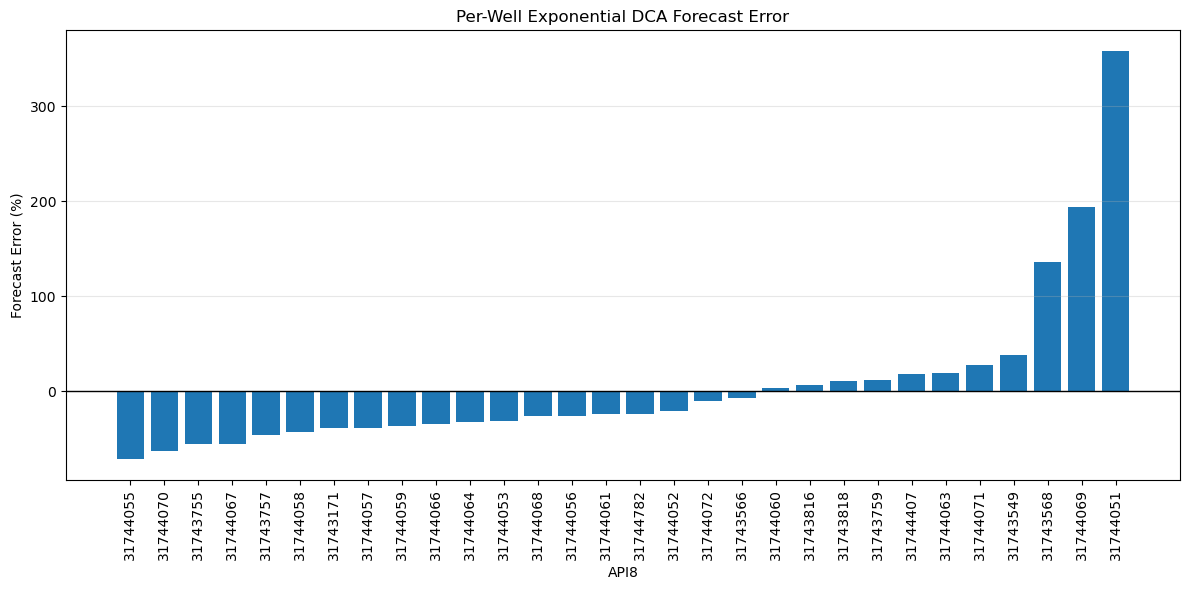

In [81]:
plt.figure(figsize=(12, 6))

plt.bar(
    per_well_results_df["api8"],
    per_well_results_df["percent_error"],
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Per-Well Exponential DCA Forecast Error")
plt.xlabel("API8")
plt.ylabel("Forecast Error (%)")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.30)
plt.tight_layout()
plt.show()

In [83]:
plt.savefig(OUTPUT_DIR / "per_well_exponential_dca_forecast_error.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [85]:
per_well_forecast_rows = []

for api8, well_data in df.groupby("api8"):
    well_curve = well_data[well_data["month_on_production"].between(1, 33)].copy()

    if len(well_curve) < FORECAST_END_MONTH:
        continue

    qi, di, fit_data = fit_exponential_decline(
        well_curve,
        month_column="month_on_production",
        rate_column="oil_bbl",
        start_month=PER_WELL_FIT_START_MONTH,
        end_month=PER_WELL_FIT_END_MONTH,
    )

    forecast_data = well_curve[
        well_curve["month_on_production"].between(FORECAST_START_MONTH, FORECAST_END_MONTH)
    ].copy()

    forecast_months = forecast_data["month_on_production"].to_numpy(dtype=float)
    forecast_data["exp_forecast_oil_bbl"] = predict_exponential(forecast_months, qi, di)
    forecast_data["forecast_error_bbl"] = forecast_data["exp_forecast_oil_bbl"] - forecast_data["oil_bbl"]
    forecast_data["forecast_percent_error"] = (
        forecast_data["forecast_error_bbl"] / forecast_data["oil_bbl"] * 100
    )

    per_well_forecast_rows.append(
        forecast_data[
            [
                "api8",
                "lease_name",
                "well_no",
                "month_on_production",
                "oil_bbl",
                "exp_forecast_oil_bbl",
                "forecast_error_bbl",
                "forecast_percent_error",
            ]
        ]
    )

per_well_forecast_df = pd.concat(per_well_forecast_rows, ignore_index=True)

per_well_forecast_df.head()

,api8,lease_name,well_no,month_on_production,oil_bbl,exp_forecast_oil_bbl,forecast_error_bbl,forecast_percent_error
0,31743171,BOHANAN-BLOCKER 3B,4H,25,2639.0,3500.184791,861.184791,32.632997
1,31743171,BOHANAN-BLOCKER 3B,4H,26,2580.0,3195.124513,615.124513,23.842035
2,31743171,BOHANAN-BLOCKER 3B,4H,27,3901.0,2916.651909,-984.348091,-25.233225
3,31743171,BOHANAN-BLOCKER 3B,4H,28,4403.0,2662.449718,-1740.550282,-39.531008
4,31743171,BOHANAN-BLOCKER 3B,4H,29,4712.0,2430.402641,-2281.597359,-48.420997


In [87]:
per_well_forecast_df.to_csv(
    OUTPUT_DIR / "per_well_exponential_dca_monthly_forecasts.csv",
    index=False,
)

In [89]:
best_fit_api8s = (
    per_well_results_df
    .sort_values("absolute_percent_error")
    .head(3)["api8"]
    .tolist()
)

best_fit_api8s

['31744060', '31743816', '31743566']

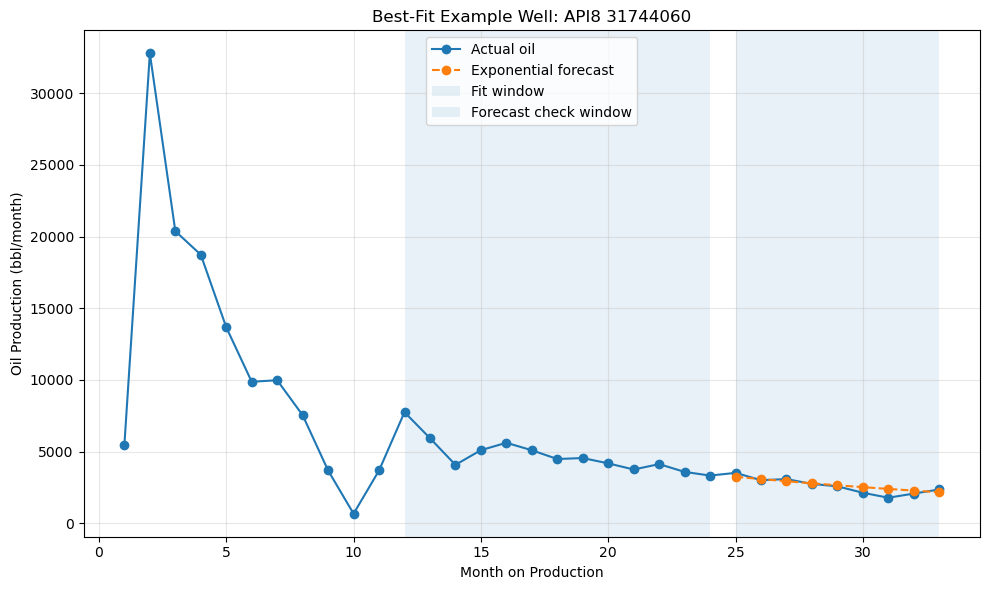

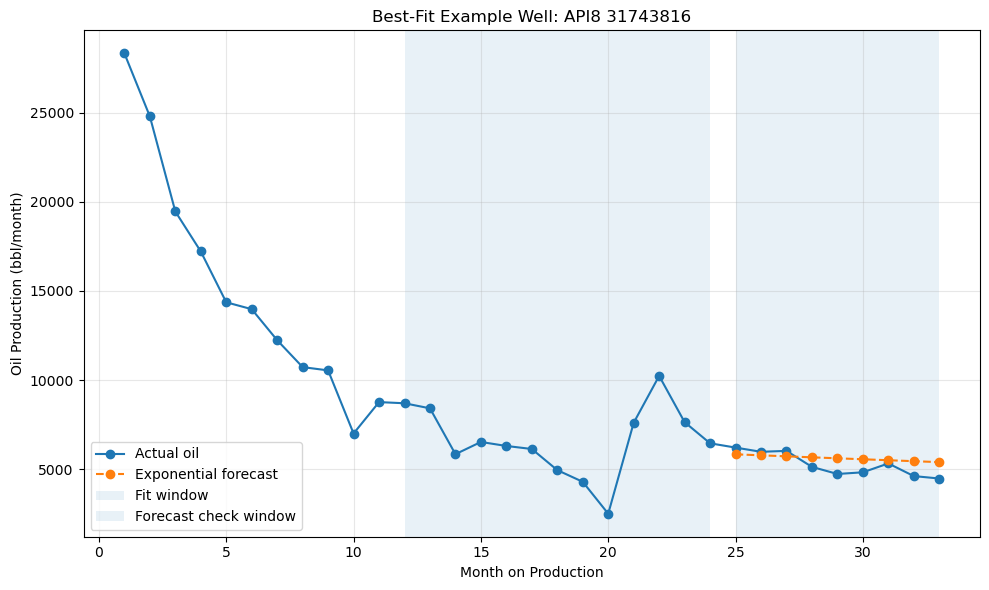

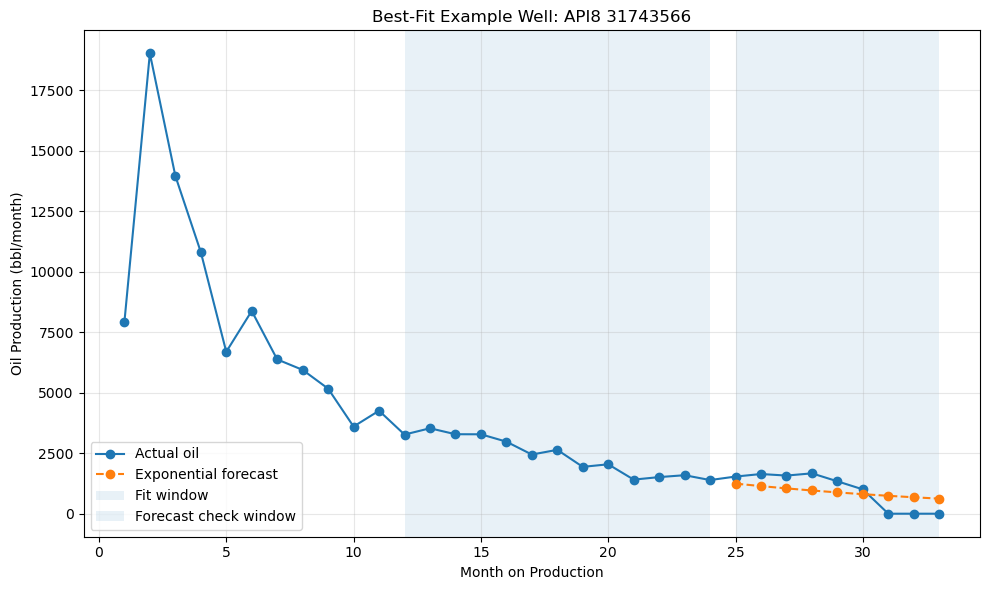

In [91]:
for api8 in best_fit_api8s:
    well_history = df[
        (df["api8"] == api8)
        & (df["month_on_production"].between(1, 33))
    ].copy()

    well_forecast = per_well_forecast_df[per_well_forecast_df["api8"] == api8].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        well_history["month_on_production"],
        well_history["oil_bbl"],
        marker="o",
        label="Actual oil",
    )

    plt.plot(
        well_forecast["month_on_production"],
        well_forecast["exp_forecast_oil_bbl"],
        marker="o",
        linestyle="--",
        label="Exponential forecast",
    )

    plt.axvspan(12, 24, alpha=0.10, label="Fit window")
    plt.axvspan(25, 33, alpha=0.10, label="Forecast check window")

    plt.title(f"Best-Fit Example Well: API8 {api8}")
    plt.xlabel("Month on Production")
    plt.ylabel("Oil Production (bbl/month)")
    plt.legend()
    plt.grid(True, alpha=0.30)
    plt.tight_layout()
    plt.show()

In [93]:
worst_fit_api8s = (
    per_well_results_df
    .sort_values("absolute_percent_error", ascending=False)
    .head(3)["api8"]
    .tolist()
)

worst_fit_api8s

['31744051', '31744069', '31743568']

In [95]:
"per_well_results_df" in globals()


True

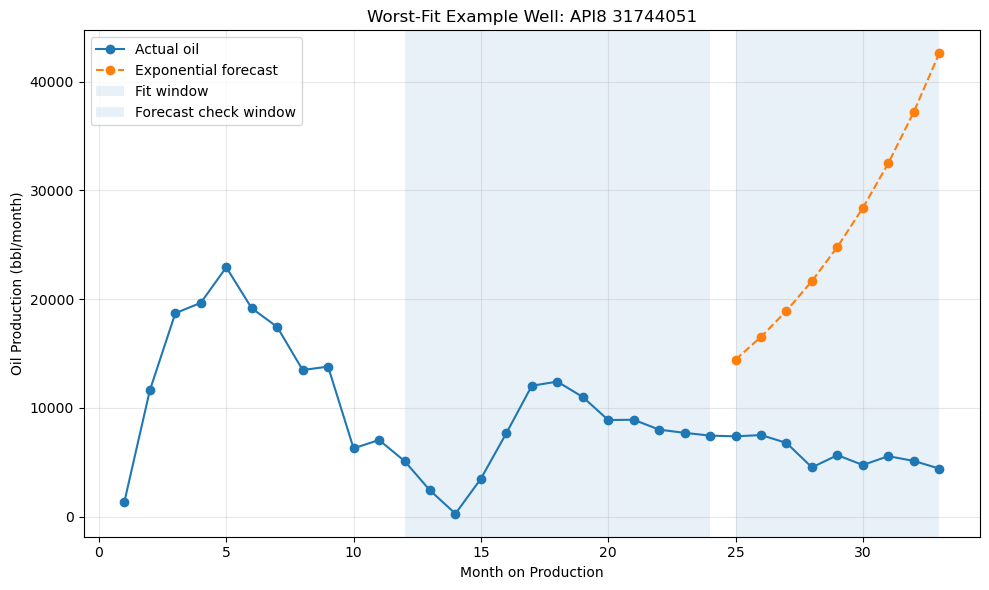

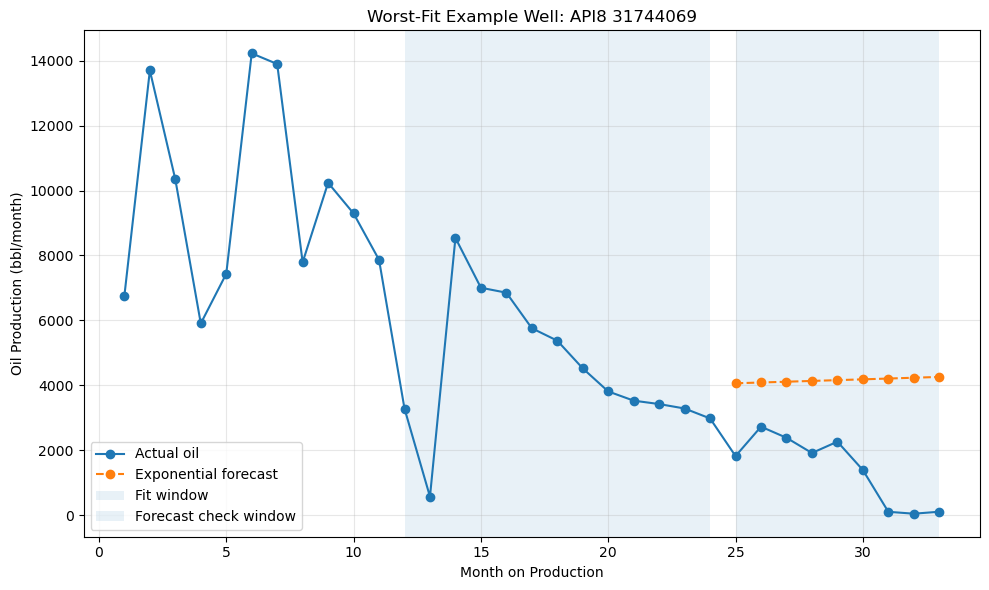

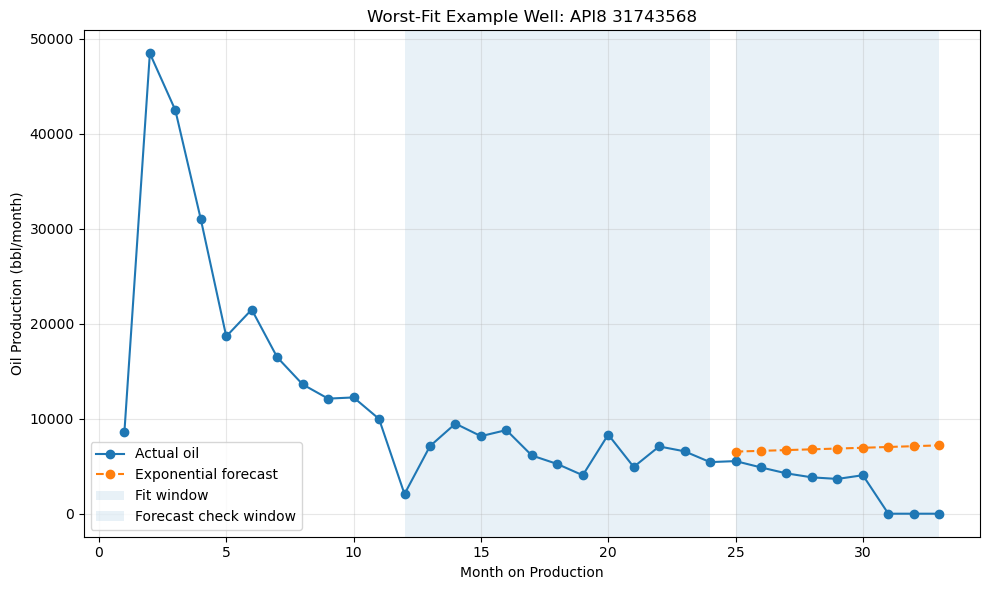

In [97]:
for api8 in worst_fit_api8s:
    well_history = df[
        (df["api8"] == api8)
        & (df["month_on_production"].between(1, 33))
    ].copy()

    well_forecast = per_well_forecast_df[per_well_forecast_df["api8"] == api8].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        well_history["month_on_production"],
        well_history["oil_bbl"],
        marker="o",
        label="Actual oil",
    )

    plt.plot(
        well_forecast["month_on_production"],
        well_forecast["exp_forecast_oil_bbl"],
        marker="o",
        linestyle="--",
        label="Exponential forecast",
    )

    plt.axvspan(12, 24, alpha=0.10, label="Fit window")
    plt.axvspan(25, 33, alpha=0.10, label="Forecast check window")

    plt.title(f"Worst-Fit Example Well: API8 {api8}")
    plt.xlabel("Month on Production")
    plt.ylabel("Oil Production (bbl/month)")
    plt.legend()
    plt.grid(True, alpha=0.30)
    plt.tight_layout()
    plt.show()

In [99]:
example_well_groups = pd.DataFrame(
    {
        "best_fit_api8": pd.Series(best_fit_api8s),
        "worst_fit_api8": pd.Series(worst_fit_api8s),
    }
)

example_well_groups


,best_fit_api8,worst_fit_api8
0,31744060,31744051
1,31743816,31744069
2,31743566,31743568


In [101]:
example_well_groups.to_csv(
    OUTPUT_DIR / "example_best_and_worst_exponential_dca_wells.csv",
    index=False,
)

## Per-Well Exponential DCA Checkpoint

We completed the first per-well exponential decline workflow.

Method:

- Each well was fit separately using monthly oil production.
- The fitting window was months 12-24.
- The forecast-check window was months 25-33.
- Forecast error was calculated by comparing forecasted oil to actual oil over months 25-33.

Outputs created:

- `per_well_exponential_dca_results.csv`
- `per_well_exponential_dca_error_summary.csv`
- `per_well_exponential_dca_monthly_forecasts.csv`
- `per_well_exponential_dca_forecast_error.png`
- `example_best_and_worst_exponential_dca_wells.csv`

Interpretation:

The exponential model works reasonably for some wells but struggles for others. This is expected because diagnostic plots suggested that some wells may show non-exponential behavior, operational noise, or changing decline regimes.

Project decision:

This notebook intentionally completes exponential DCA as the baseline. Hyperbolic and harmonic decline models, including b-factor estimation, should be evaluated in a separate follow-up notebook.

In [103]:
from pathlib import Path
import os

print("Current working directory:")
print(Path.cwd())

print("\nFiles in this folder:")
for path in sorted(Path.cwd().glob("*.ipynb")):
    print(path.name)

Current working directory:
C:\Users\tawac

Files in this folder:
02_exponential_decline_dca.ipynb
02_exponential_decline_dca_v1.ipynb
03_Hyperbolic_decline_dca-v1.ipynb
03_Hyperbolic_decline_dca.ipynb
04_Harmonic Decline_dca.ipynb
05_DCA Model Comparison.ipynb
EDA_mobile banking.ipynb
Untitled.ipynb
Untitled1.ipynb
Untitled2.ipynb
wasana.ipynb
